In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv


# PIMA INDIANS DIABETES PREDICTION USING ANN + KERAS TUNER

# 1. IMPORT LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import keras_tuner as kt

2026-05-26 13:37:14.918279: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779802635.146444      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779802635.209678      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779802635.735869      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779802635.735922      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779802635.735925      23 computation_placer.cc:177] computation placer alr

 # 2. LOAD DATASET

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv")

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# 3.CHECKING SHAPE

In [4]:
df.shape

(768, 9)

# 4.COLUMNS NAME

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# 5. CHECKING MISSING VALUE

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# 6. GETTIING INFORMATION

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# 7.GETTING DESCRIBE 

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 8. INPUT AND OUTPUT

In [9]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# 9. TRAIN TEST SPLIT

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# 10. FEATURE SCALING

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 11. MODEL BUILDING FUNCTION

In [12]:
def build_model(hp):

    model = Sequential()

    # ========================================================
    # INPUT LAYER
    # ========================================================

    model.add(
        Dense(
            units=hp.Choice(
                "input_units",
                values=[32, 64, 96, 128]
            ),

            activation=hp.Choice(
                "input_activation",
                values=["relu", "tanh"]
            ),

            kernel_initializer="he_normal",

            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float(
                    "input_l2",
                    min_value=1e-5,
                    max_value=1e-3,
                    sampling="log"
                )
            ),

            input_dim=X_train.shape[1]
        )
    )

    model.add(BatchNormalization())

    model.add(
        Dropout(
            hp.Float(
                "input_dropout",
                min_value=0.1,
                max_value=0.3,
                step=0.1
            )
        )
    )

    # ========================================================
    # HIDDEN LAYERS
    # ========================================================

    for i in range(
        hp.Int("num_hidden_layers", 1, 2)
    ):

        model.add(
            Dense(
                units=hp.Choice(
                    f"hidden_units_{i}",
                    values=[32, 64, 96, 128]
                ),

                activation=hp.Choice(
                    f"hidden_activation_{i}",
                    values=["relu", "tanh"]
                ),

                kernel_initializer="he_normal",

                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float(
                        f"l2_{i}",
                        min_value=1e-5,
                        max_value=1e-3,
                        sampling="log"
                    )
                )
            )
        )

        model.add(BatchNormalization())

        model.add(
            Dropout(
                hp.Float(
                    f"dropout_{i}",
                    min_value=0.1,
                    max_value=0.3,
                    step=0.1
                )
            )
        )

    # ========================================================
    # OUTPUT LAYER
    # ========================================================

    model.add(
        Dense(
            1,
            activation="sigmoid"
        )
    )

    # ========================================================
    # LEARNING RATE
    # ========================================================

    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.1,0.001,0.5,0.005,0.002,0.0001],
    )

    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer_name = hp.Choice(
        "optimizer",
        values=["adam", "adamax"]
    )

    if optimizer_name == "adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    else:

        optimizer = keras.optimizers.Adamax(
            learning_rate=learning_rate
        )

    # ========================================================
    # COMPILE MODEL
    # ========================================================

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",

        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

# 12. CALLBACKS

In [13]:
early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

# 13. CLASS WEIGHTS

In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.7671875), 1: np.float64(1.435672514619883)}


# 14. KERAS TUNER

In [15]:
tuner = kt.Hyperband(
    build_model,

    objective=kt.Objective(
        "val_auc",
        direction="max"
    ),

    max_epochs=50,

    factor=3,

    directory="keras_tuner",

    project_name="pima_diabetes_ann"
)

I0000 00:00:1779802661.806982      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779802661.813355      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# 15. START HYPERPARAMETER SEARCH

In [16]:
tuner.search(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    verbose=1,

    epochs=50,

    batch_size=16,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Trial 90 Complete [00h 00m 15s]
val_auc: 0.8857557773590088

Best val_auc So Far: 0.8986918926239014
Total elapsed time: 00h 17m 48s


# 16. BEST HYPERPARAMETERS

In [17]:
best_hps = tuner.get_best_hyperparameters(1)[0]

print("\nBest Hyperparameters:\n")

for param in best_hps.values:
    print(param, ":", best_hps.get(param))


Best Hyperparameters:

input_units : 64
input_activation : relu
input_l2 : 0.0004954762432211856
input_dropout : 0.2
num_hidden_layers : 1
hidden_units_0 : 96
hidden_activation_0 : tanh
l2_0 : 0.0007105825829632309
dropout_0 : 0.2
learning_rate : 0.005
optimizer : adam
hidden_units_1 : 96
hidden_activation_1 : relu
l2_1 : 0.00012699650141803268
dropout_1 : 0.2
tuner/epochs : 2
tuner/initial_epoch : 0
tuner/bracket : 3
tuner/round : 0


# 17. BUILD BEST MODEL

In [18]:
best_model = tuner.hypermodel.build(best_hps)

best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,553 (29.50 KB)

 Trainable params: 7,233 (28.25 KB)

 Non-trainable params: 320 (1.25 KB)

# 18. TRAIN BEST MODEL

In [19]:
history = best_model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=100,

    batch_size=16,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.6202 - auc: 0.6478 - loss: 1.0012 - val_accuracy: 0.7805 - val_auc: 0.8549 - val_loss: 0.6692 - learning_rate: 0.0050
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7185 - auc: 0.7863 - loss: 0.7807 - val_accuracy: 0.7561 - val_auc: 0.8645 - val_loss: 0.6810 - learning_rate: 0.0050
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7039 - auc: 0.7858 - loss: 0.7417 - val_accuracy: 0.8049 - val_auc: 0.8711 - val_loss: 0.6480 - learning_rate: 0.0050
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6830 - auc: 0.7721 - loss: 0.7983 - val_accuracy: 0.7073 - val_auc: 0.8326 - val_loss: 0.6827 - learning_rate: 0.0050
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7310 - auc: 0.8262 - loss: 0.6979 - val_accuracy: 0.7724 - val_auc: 0.8628 - val_loss: 0.6307 - learning_rate: 0.0050
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7775 - auc: 0.8437

# 19. EVALUATE MODEL

In [20]:
loss, accuracy, auc = best_model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", accuracy)
print("Test AUC :", auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.7520 - auc: 0.8107 - loss: 0.7420

Test Accuracy : 0.7532467246055603
Test AUC : 0.8086112141609192


# 20. PREDICTIONS

In [21]:
y_pred_prob = best_model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


# 21. METRICS

In [22]:
from sklearn.metrics import roc_auc_score

print("\nAccuracy Score:\n")
print(accuracy_score(y_test, y_pred))

print("\nROC-AUC Score:\n")
print(roc_auc_score(y_test, y_pred_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy Score:

0.7532467532467533

ROC-AUC Score:

0.8077777777777777

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.71      0.79       100
           1       0.61      0.83      0.70        54

    accuracy                           0.75       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.79      0.75      0.76       154


Confusion Matrix:

[[71 29]
 [ 9 45]]


# 22. TRAINING CURVES

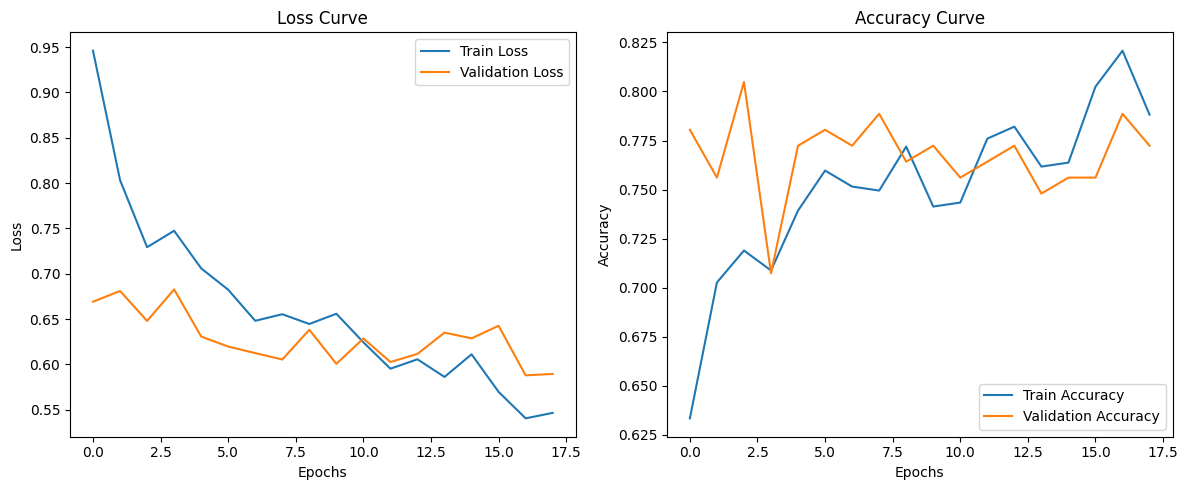

In [23]:
plt.figure(figsize=(12, 5))


# LOSS CURVE

plt.subplot(1, 2, 1)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()


# ACCURACY CURVE

plt.subplot(1, 2, 2)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# 23. SAVE MODEL

In [24]:
best_model.save("pima_diabetes_model.h5")

print("\nModel Saved Successfully!")


Model Saved Successfully!


# 24. LOAD MODEL

In [25]:
loaded_model = tf.keras.models.load_model(
    "pima_diabetes_model.h5"
)

print("\nModel Loaded Successfully!")


Model Loaded Successfully!
